# Tree Methods OEFENING


## DOEL: Maak een model wat voorspelt of een klant zijn contract zal stopzetten of niet (churn)

----


## Voer de vetgedrukte taken uit!

## Deel 0: Imports en Inlezen van de data

**TAAK: Run de cellen hieronder om de libraries te importeren en de data in te lezen. De data file is "Telco-Customer-Churn.csv"**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Deel 1: Controle van de data

**TAAK: Controleer met .info() de datatypes en non-null waarden in het dataframe.**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


**TAAK: Maak een snelle statistische samenvatting van de numerieke kolommen met .describe(), je zult merken dat veel kolommen categorisch zijn, wat betekent dat je ze uiteindelijk zult moeten omzetten naar dummy variabelen.**

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


# Deel 2:  Verkennende Data Analyse

## Algemene verkenning van de features

**TAAK: Ga na of er NaN waarden zijn door deze per feature weer te geven.**

In [7]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**TAAK: Controleer en visualiseer of de dataset gebalanceerd is met een Count Plot van de klasse labels (churn).**

<Axes: xlabel='Churn', ylabel='count'>

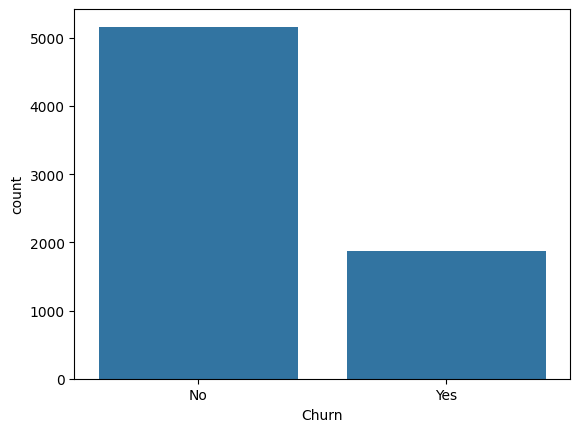

In [9]:
sns.countplot(data=df, x="Churn")

**TAAK: Verken de distrbutie van TotalCharges in functie van de Churn categorieën met een Box Plot.**

<Axes: xlabel='Churn', ylabel='TotalCharges'>

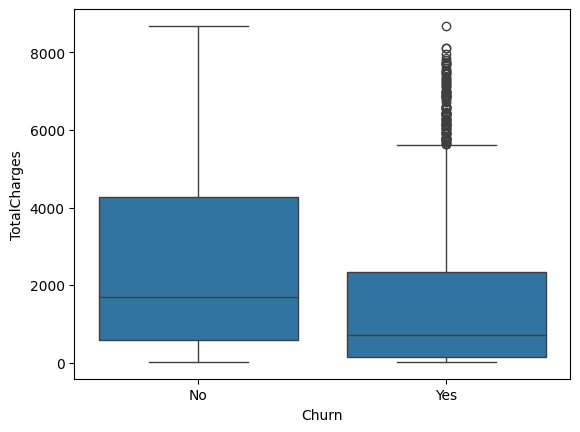

In [10]:
sns.boxplot(data=df, x="Churn", y="TotalCharges")

**TAAK: Maak een boxplot om de distributie van TotalCharges per Contract type te tonen.  Gebruik een hue gebaseerd op de Churn klasse.**

<Axes: xlabel='Contract', ylabel='TotalCharges'>

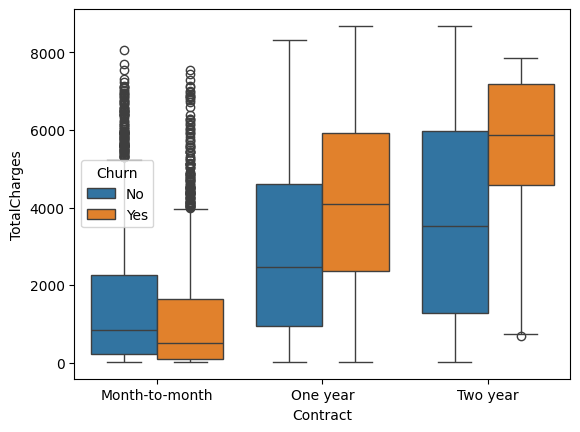

In [11]:
sns.boxplot(data=df, x="Contract", y="TotalCharges", hue="Churn")

**TAAK: Maak een bar plot om de correlatie van de features met het class label te tonen.  Bedenk dat categorische features moeten worden geconverteerd naar dummy variabelen, aangezien je correlatie alleen voor numerieke features kan berekenen.**
    ['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 
     'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'InternetService',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

***! Gebruik enkel de opgelijste features om de correlatie te bepalen.  Je doet dit best niet voor elke feature aangezien sommige features teveel unieke instanties hebben voor deze analyse (vb customerID)***

In [11]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [18]:
selected_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 
     'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'InternetService',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
df_corr = pd.get_dummies(df[selected_cols]).corr()

In [19]:
df_corr.columns

Index(['SeniorCitizen', 'gender_Female', 'gender_Male', 'Partner_No',
       'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'OnlineSecurity_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'StreamingTV_No',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaperlessBilling_No', 'PaperlessBilling_Yes'

In [21]:
rel_of_interest = df_corr['Churn_Yes'].sort_values().iloc[1:-1]

In [ ]:
plt.figure(figsize=(10,4),dpi=200)
sns.barplot(x=rel_of_interest.index,y=rel_of_interest.values)
plt.title("Feature Correlation to Yes Churn")
plt.xticks(rotation=90);

---
---

# Deel 3: Churn Analyse

**Dit deel gaat in op het segmenteren van klanten op basis van de tijd dat ze al klant zijn, om zo groepen met gelijkaardige eigenschappen (cohorts) te maken - en de verschillen tussen verschillende cohorts te kunnen onderzoeken.**

**TAAK: Welke 3 contract types zijn beschikbaar?**

In [22]:
df.Contract.unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [23]:
df.Contract.value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

**TAAK: Maak een histogram wat de distributie van de retentie ('tenure') weergeeft, wat overeenkomt met het aantal maanden dat een klant een klant is of was.**

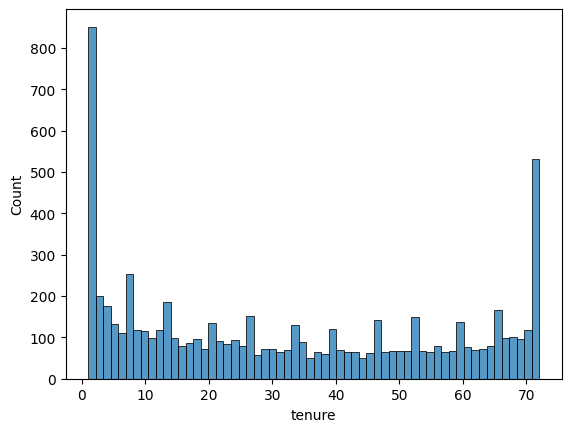

In [24]:
sns.histplot(data=df,x='tenure',bins=60);

De 2 meest 'populaire' categorieën zijn blijkbaar degene die ofwel snel afhaken, ofwel heel lang klant blijven...

**TAAK: Gebruik de seaborn documentatie om een histogram op te maken wat gesplitst is op 2 extra features, Churn en Contract om te zien of het soort contract (maandelijks opzegbaar tot meerjarencontract) een invloed heeft op churn.**

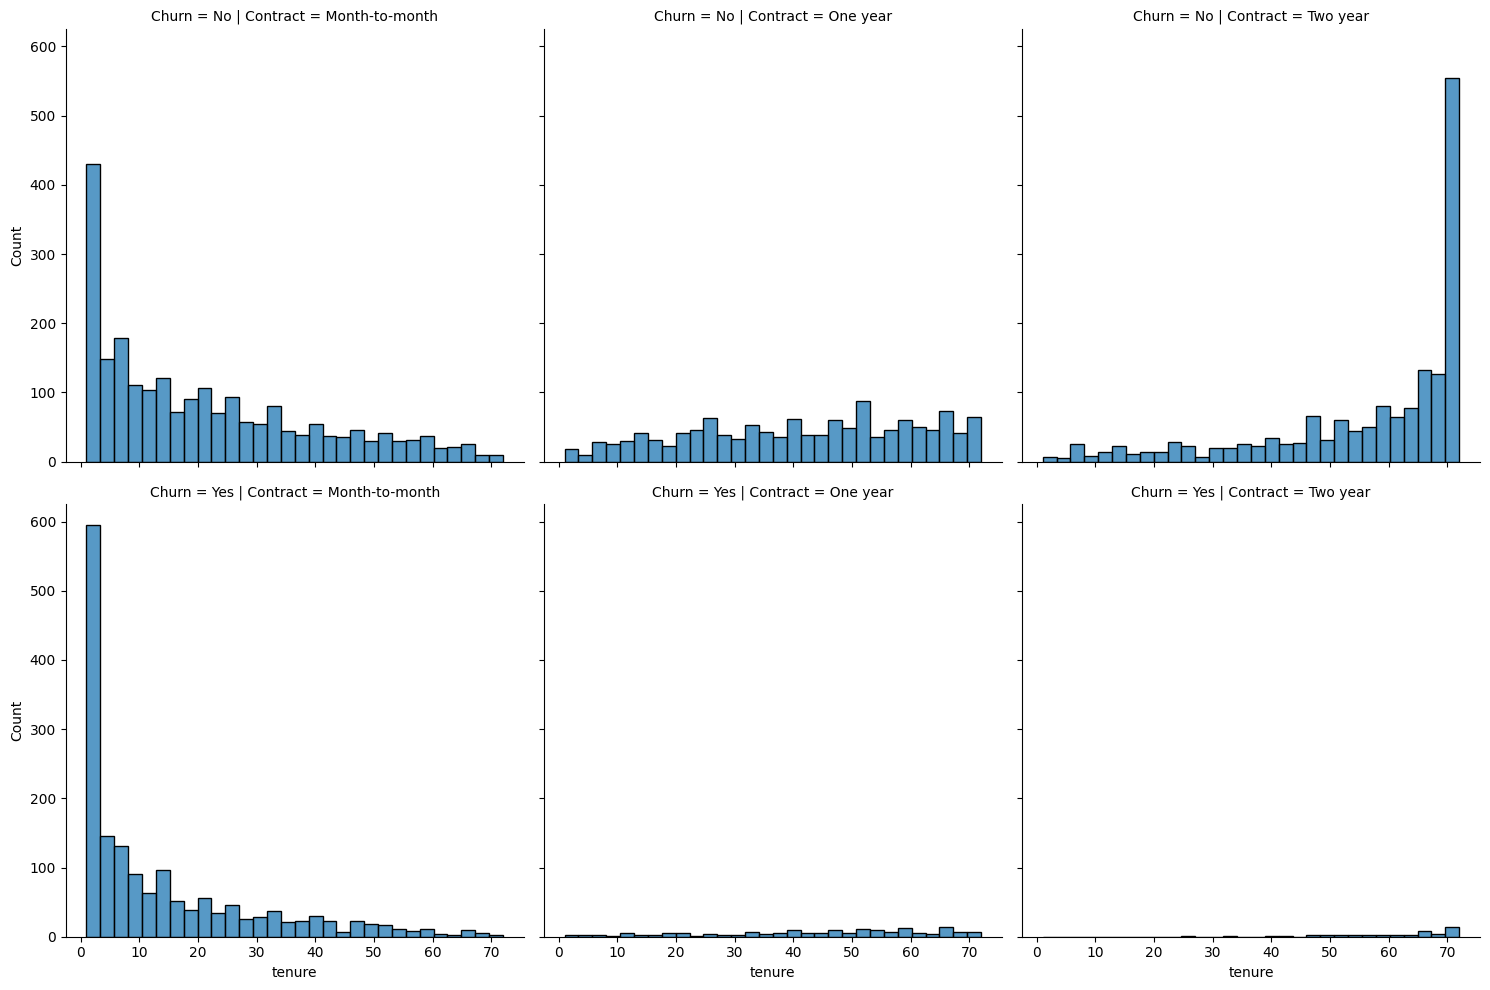

In [32]:
sns.displot(data=df,x='tenure',col='Contract',row='Churn',bins=30);

**TAAK: Maak een scatter plot van Total Charges versus Monthly Charges, met een hue op basis van Churn.**

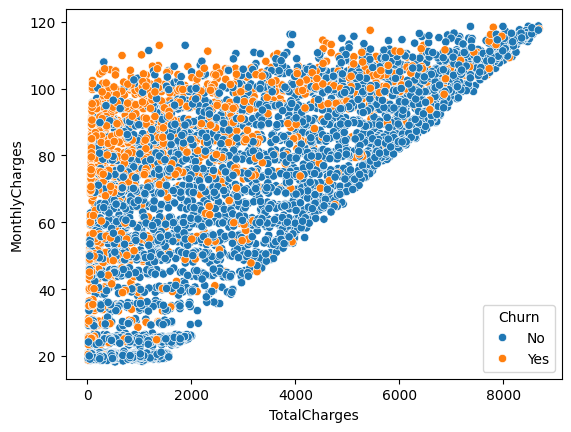

In [34]:
sns.scatterplot(data=df, x='TotalCharges', y='MonthlyCharges', hue='Churn');

### Maken van Cohorts gebaseerd op de retentie ('Tenure')

**We beginnen met elke retentieperiode (1, 2, 3, ... maanden) als een eigen cohort te beschouwen.**

**TAAK: Bereken de churn rate (% met Yes churn) met elke unieke retentieperiode als een afzonderlijk cohort. Bijvoorbeeld, het cohort met een retentie van 1 maand zou een Churn rate van 61.99% moeten hebben. Je zou cohorts met 1 tot 72 maanden moeten hebben, waarbij de churn rate afneemt in functie van de retentietijd.  Dit is logisch want hoe langer je reeds een dienst gebruikt, hoe minder waarschijnlijk dat je deze zal stopzetten.**

In [64]:
churn_rates = df.groupby('tenure')['Churn'].value_counts(normalize=True)

In [67]:
yes_churns = round(churn_rates.unstack(level=1)["Yes"] * 100, 2)
yes_churns

tenure
1     61.99
2     51.68
3     47.00
4     47.16
5     48.12
      ...  
68     9.00
69     8.42
70     9.24
71     3.53
72     1.66
Name: Yes, Length: 72, dtype: float64

**TAAK: Je hebt nu de Churn Rate per tenure group van 1 tot 72 maanden.  Maak een plot die de churn rate per aantal maanden retentie toont.**

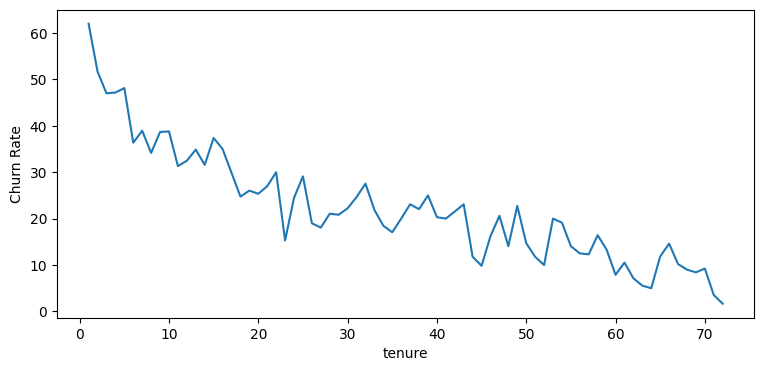

In [72]:
plt.figure(figsize=(9,4))
sns.lineplot(x=yes_churns.index, y=yes_churns.values)
plt.ylabel('Churn Rate');

### Verbreden van de Cohort groepen
**TAAK: Maak een nieuwe kolom genaamd 'Tenure Cohort' die op basis van de waarden in de tenure kolom column values 4 afzonderlijke categorieën maakt:**
   * '0-12 Months'
   * '24-48 Months'
   * '12-24 Months'
   * 'Over 48 Months'    

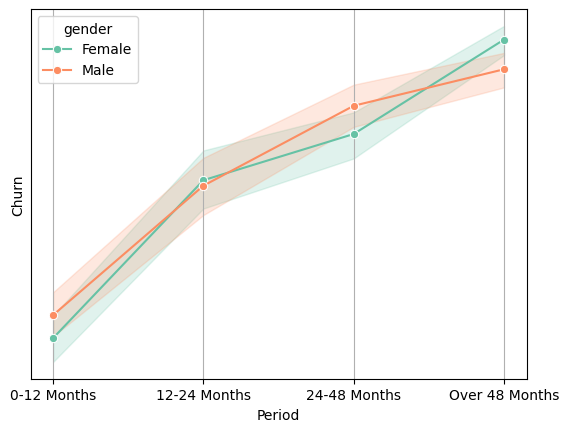

In [80]:
df_trend = df.copy()
df_trend["Period"] = pd.cut(df.tenure, bins=[0, 12, 24, 48, 70], labels=['0-12 Months', '12-24 Months', '24-48 Months', 'Over 48 Months'])
sns.lineplot(data=df_trend, x='Period', y='Churn', hue='gender', palette='Set2', marker='o')
plt.grid()

In [81]:
def cohort(tenure):
    if tenure < 13:
        return '0-12 Months'
    elif tenure < 25:
        return '12-24 Months'
    elif tenure < 49:
        return '24-48 Months'
    else:
        return "Over 48 Months"
    
df['Tenure Cohort'] = df['tenure'].apply(cohort)

In [82]:
df.sample(5)[['tenure','Tenure Cohort']]

,tenure,Tenure Cohort
3230,61,Over 48 Months
331,8,0-12 Months
2916,9,0-12 Months
1170,14,12-24 Months
728,65,Over 48 Months


**TAAK: Maak een scatterplot van de Total Charges versus Monthly Charges, met kleur op basis van de Tenure Cohort zoals gemaakt in de voorgaande taak.**

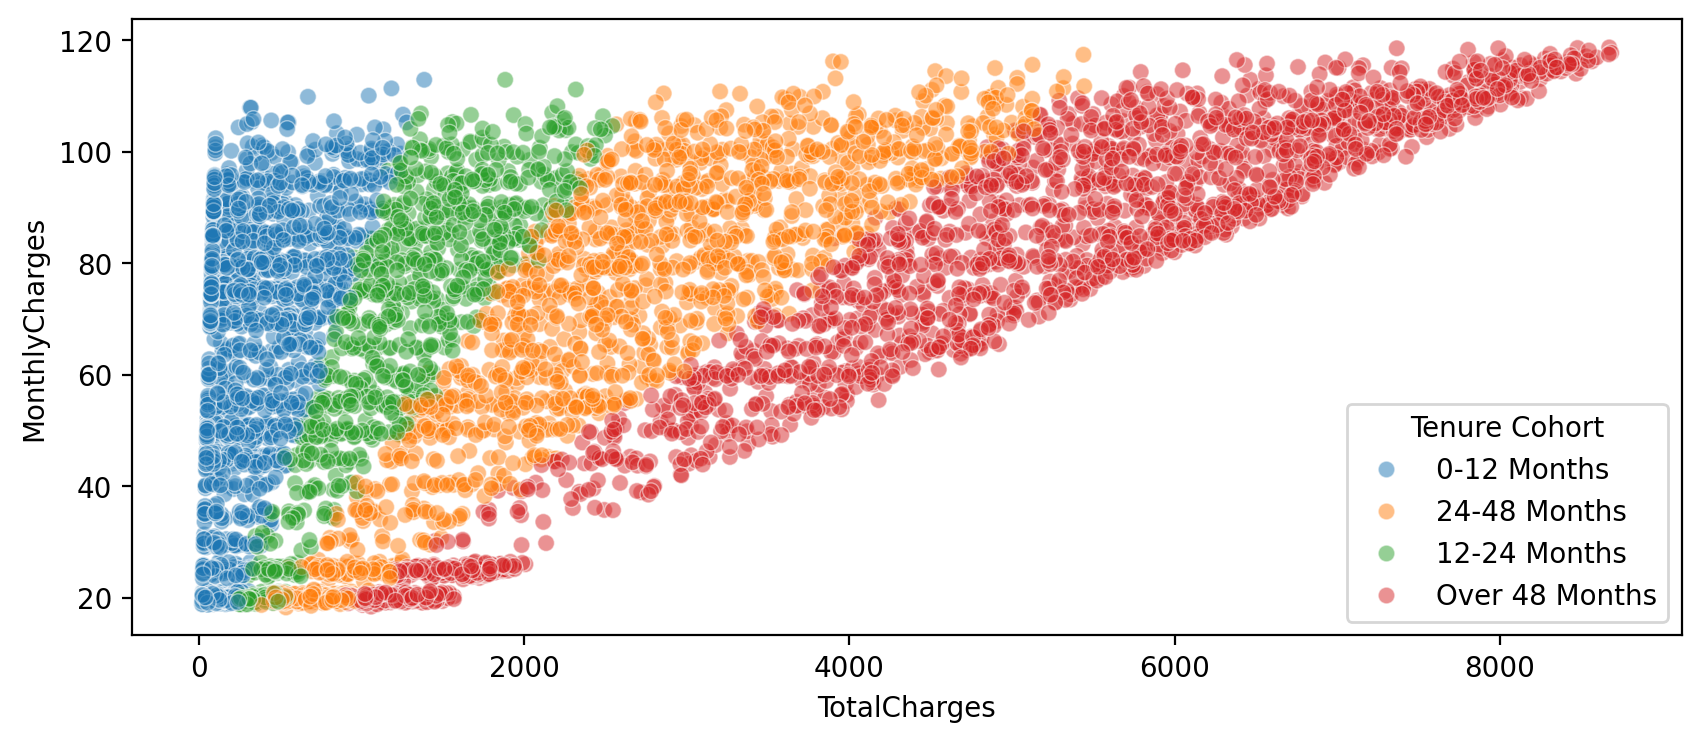

In [89]:
plt.figure(figsize=(10,4),dpi=200)
sns.scatterplot(data=df,x='TotalCharges',y='MonthlyCharges',hue='Tenure Cohort', linewidth=0.5,alpha=0.5,palette='tab10');

**TAAK: Maak een count plot die de churn per cohort weergeeft.**

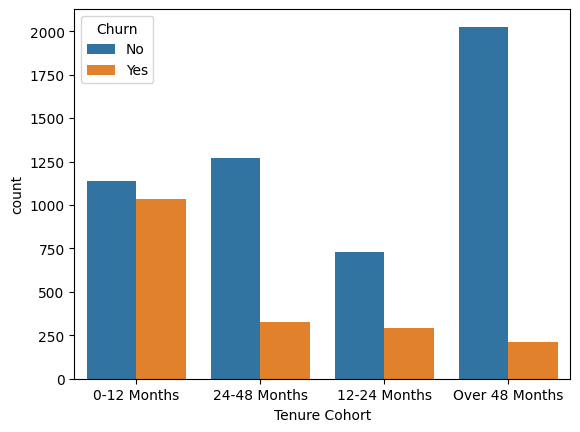

In [96]:
sns.countplot(data=df,x='Tenure Cohort',hue='Churn');

**TAAK: Maak een grid van Count Plots die de aantallen per Tenure Cohort tonen, opgedeeld per contract type en met kleuren (hue) volgens de Churn.**

<Figure size 1000x400 with 0 Axes>

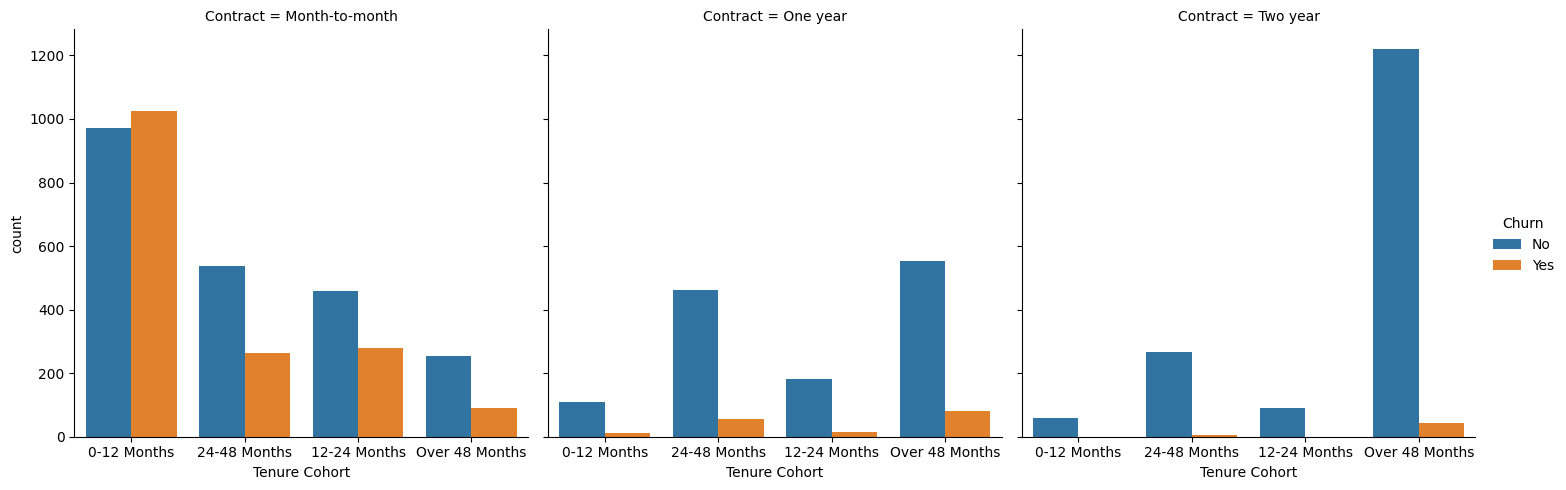

In [100]:
plt.figure(figsize=(10,4))
sns.catplot(data=df,x='Tenure Cohort',hue='Churn',col='Contract',kind='count');

-----

# Deel 4: Bouwen van een voorspellend model

**We gaan 4 verschillende tree based methods gebruiken: een enkele Decision Tree, Random Forest, AdaBoost en Gradient Boosting. Voel je vrij om nog andere supervised learning modellen aan de vergelijking toe te voegen!**


## Enkele Decision Tree

**TAAK : Splits de data in X features en y label. Maak dummy variabelen waar nodig en ga na welke features niet nuttig zijn, waarna je deze mag verwijderen.**

In [101]:
X = df.drop(['Churn','customerID'],axis=1)
X = pd.get_dummies(X,drop_first=True)
y = df['Churn']

**TAAK: Voer een train test split uit, waarbij je 10% van de data als test set neemt.  Gebruik een random state van 101.**

In [103]:
from sklearn.model_selection import train_test_split

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

**Decision Tree Perfomantie. Voer de volgende taken uit:**  

1. Train een enkel decision tree model (je mag gerust grid search gebruiken om de optimale hyperparameters te vinden).
2. Evalueer de prestatie-indicatoren van de decision tree, inclusief het classificatierapport en het plotten van een confusion matrix.  
3. Bereken de belangrijkheid van de features voor de decision tree  
4. OPTIONEEL: Plot je tree maar let op: in functie van de opties kan dit je notebook laten crashen als je hem toont met plot_tree.  **Bewaar dus eerst je werk, en let op welke parameters je kiest alvorens dit te proberen!**

In [105]:
from sklearn.tree import DecisionTreeClassifier

In [106]:
dt = DecisionTreeClassifier(max_depth=6)
dt.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [107]:
preds = dt.predict(X_test)

In [111]:
preds[:10]

array(['Yes', 'No', 'No', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'No'],
      dtype=object)

In [112]:
preds_pr = dt.predict_proba(X_test)
preds_pr[:10]

array([[0.36094675, 0.63905325],
       [0.91666667, 0.08333333],
       [0.57831325, 0.42168675],
       [0.20095694, 0.79904306],
       [0.93333333, 0.06666667],
       [0.99223947, 0.00776053],
       [0.35260116, 0.64739884],
       [0.99223947, 0.00776053],
       [0.28125   , 0.71875   ],
       [0.56666667, 0.43333333]])

In [108]:
from sklearn.tree import plot_tree

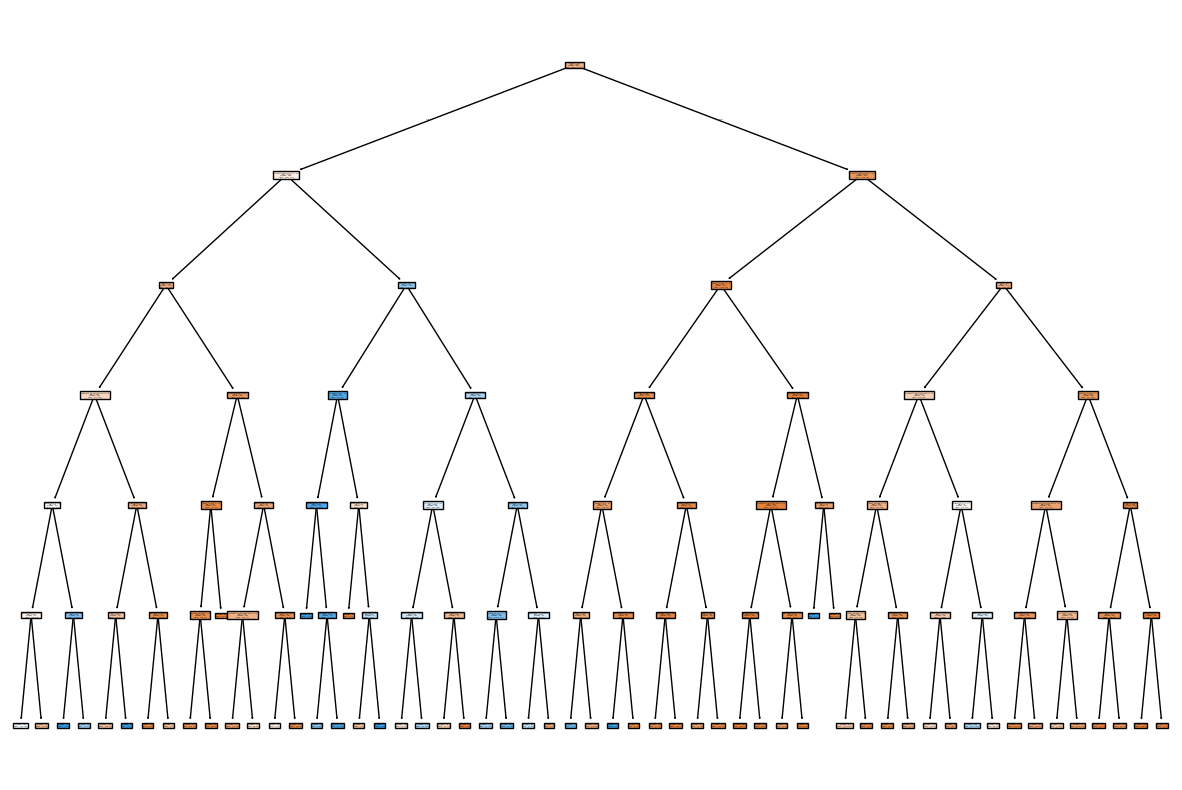

In [109]:
plt.figure(figsize=(15,10))
plot_tree(dt,filled=True,feature_names=X.columns);

In [ ]:
# for DT performance check and the rest of the notebook see Tree-Methods_opl.ipynb